###Modelling & Evaluation

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Case Studies/BCG-X/datasets/data_for_predictions.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 64 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Unnamed: 0                                  14606 non-null  int64  
 1   id                                          14606 non-null  object 
 2   cons_12m                                    14606 non-null  float64
 3   cons_gas_12m                                14606 non-null  float64
 4   cons_last_month                             14606 non-null  float64
 5   forecast_cons_12m                           14606 non-null  float64
 6   forecast_discount_energy                    14606 non-null  float64
 7   forecast_meter_rent_12m                     14606 non-null  float64
 8   forecast_price_energy_off_peak              14606 non-null  float64
 9   forecast_price_energy_peak                  14606 non-null  float64
 10  forecast_p

In [ ]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [ ]:
#Separate target variables from independent variables
X = df.drop(columns=['id','churn'])
y = df['churn']

Data Sampling

Split our given dataset into train-validation-test sets in the ratio of 7:2:1

* Training  = 70%
* Validation  = 20%
* Test  = 10%

In [ ]:
#Splitting Dataset
X_temp,X_test,y_temp,y_test = train_test_split(X,y,test_size=0.1,random_state=42)
X_train,X_valid,y_train,y_valid = train_test_split(X_temp,y_temp,test_size=(0.2/0.9),random_state=42)

Model Training

Once again, we are using a `Random Forest` classifier in this example.

Some additional advantages of the random forest classifier include:

- The random forest uses a rule-based approach instead of a distance calculation and so features do not need to be scaled
- It is able to handle non-linear parameters better than linear based models

On the flip side, some disadvantages of the random forest classifier include:

- The computational power needed to train a random forest on a large dataset is high, since we need to build a whole ensemble of estimators.
- Training time can be longer due to the increased complexity and size of thee ensemble

Using Cross Validation to determine the best parameters that facilitate model training.

**RandomizedSearchCV** --> For larger hyperparameter space

* n_estimators ranges from 10 to 1000 i.e. random forest wll consist of decision trees from 100 to 1000
* max_features ranges from 1 to 10
* no. of iterations = 10
* validation sets = 5


In [ ]:
model = RandomForestClassifier(random_state=42)

param_distrib = {
    'n_estimators':randint(10,100),
    'max_features':randint(2,8)
}

random_search = RandomizedSearchCV(model,param_distributions=param_distrib,n_iter=10,cv=5,random_state=42)
random_search.fit(X_train,y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   param_distributions={'max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79e1377d46b0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79e1311989e0>},
                   random_state=42)

In [ ]:
#Choosing the final model as best estimator for the final model
final_model = random_search.best_estimator_
final_model.feature_importances_

array([0.04775912, 0.01072618, 0.03496851, 0.04502694, 0.00147426,
       0.04775319, 0.02201015, 0.01149269, 0.00481089, 0.00481758,
       0.03028867, 0.04358335, 0.04722004, 0.00862385, 0.04700759,
       0.03422618, 0.02882383, 0.01535678, 0.01260349, 0.01999368,
       0.00596328, 0.00590915, 0.03001942, 0.01542591, 0.01258998,
       0.01913346, 0.00970804, 0.0071376 , 0.00717524, 0.0024439 ,
       0.00241992, 0.01840638, 0.00966097, 0.00595484, 0.02363467,
       0.00723672, 0.02740194, 0.0132793 , 0.02632086, 0.01402375,
       0.00554922, 0.01359283, 0.01519749, 0.00856665, 0.01629045,
       0.00499671, 0.00149044, 0.00473658, 0.01768132, 0.03090411,
       0.01498545, 0.02773099, 0.01582721, 0.0048774 , 0.00289935,
       0.00734248, 0.00344295, 0.00429774, 0.00500574, 0.0041492 ,
       0.00802343])

 Evaluation

Now let's evaluate how well this trained model performs on the validation set.

We are going to use 3 metrics to evaluate performance:

- Accuracy = the ratio of correctly predicted observations to the total observations
- Precision = the ability of the classifier to not label a negative sample as positive
- Recall = the ability of the classifier to find all the positive samples

The reason why we are using these three metrics is because a simple accuracy is not always a good measure to use. To give an example, let's say you're predicting heart failures with patients in a hospital and there were 100 patients out of 1000 that did have a heart failure.

If you predicted 80 out of 100 (80%) of the patients that did have a heart failure correctly, you might think that you've done well! However, this also means that you predicted 20 wrong and what may the implications of predicting these remaining 20 patients wrong? Maybe they miss out on getting vital treatment to save their lives.

As well as this, what about the impact of predicting negative cases as positive (people not having heart failure being predicted that they did), maybe a high number of false positives means that resources get used up on thee wrong people and a lot of time is wasted when they could have been helping the real heart failure sufferers.

This is just an example, but it illustrates why other performance metrics are necessary such `Precision` and `Recall`, which are good measures to use in a classification scenario.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [ ]:
valid_predictions = final_model.predict(X_valid)
tn, fp, fn, tp = confusion_matrix(y_valid, valid_predictions).ravel()

In [ ]:
y_valid.value_counts()

,count
churn,
0,2631
1,291


In [ ]:
print(f"True positives: {tp}")
print(f"False positives: {fp}")
print(f"True negatives: {tn}")
print(f"False negatives: {fn}\n")

print(f"Accuracy: {accuracy_score(y_valid, valid_predictions)}")
print(f"Precision: {precision_score(y_valid, valid_predictions)}")
print(f"Recall: {recall_score(y_valid, valid_predictions)}")

True positives: 15
False positives: 1
True negatives: 2630
False negatives: 276

Accuracy: 0.905201916495551
Precision: 0.9375
Recall: 0.05154639175257732


- Within the test set about 10% of the rows are churners (churn = 1).
- Looking at the true negatives, we have 2630 out of 2631. This means that out of all the negative cases (churn = 0), we predicted 2630 as negative (hence the name True negative). This is great!
- Looking at the false negatives, this is where we have predicted a client to not churn (churn = 0) when in fact they did churn (churn = 1). This number is quite high at 276, we want to get the false negatives to as close to 0 as we can, so this would need to be addressed when improving the model.
- Looking at false positives, this is where we have predicted a client to churn when they actually didnt churn. For this value we can see there is only 1 case, which is great!
- With the true positives, we can see that in total we have 291 clients that churned in the test dataset. However, we are only able to correctly identify 15 of those 291, which is very poor.
- Looking at the accuracy score, this is very misleading! Hence the use of precision and recall is important. The accuracy score is high, but it does not tell us the whole story.
- Looking at the precision score, this shows us a score of 0.93 which is vey good indeed, but can be improved.
- However, the recall shows us that the classifier has a very poor ability to identify positive samples. This would be the main concern for improving this model!


Model Understanding

A simple way of understanding the results of a model is to look at feature importances. Feature importances indicate the importance of a feature within the predictive model, there are several ways to calculate feature importance, but with the Random Forest classifier, we're able to extract feature importances using the built-in method on the trained model. In the Random Forest case, the feature importance represents the number of times each feature is used for splitting across all trees.

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
feature_importances = pd.DataFrame({
    'features': X_train.columns,
    'importance': final_model.feature_importances_
}).sort_values(by='importance', ascending=True).reset_index()


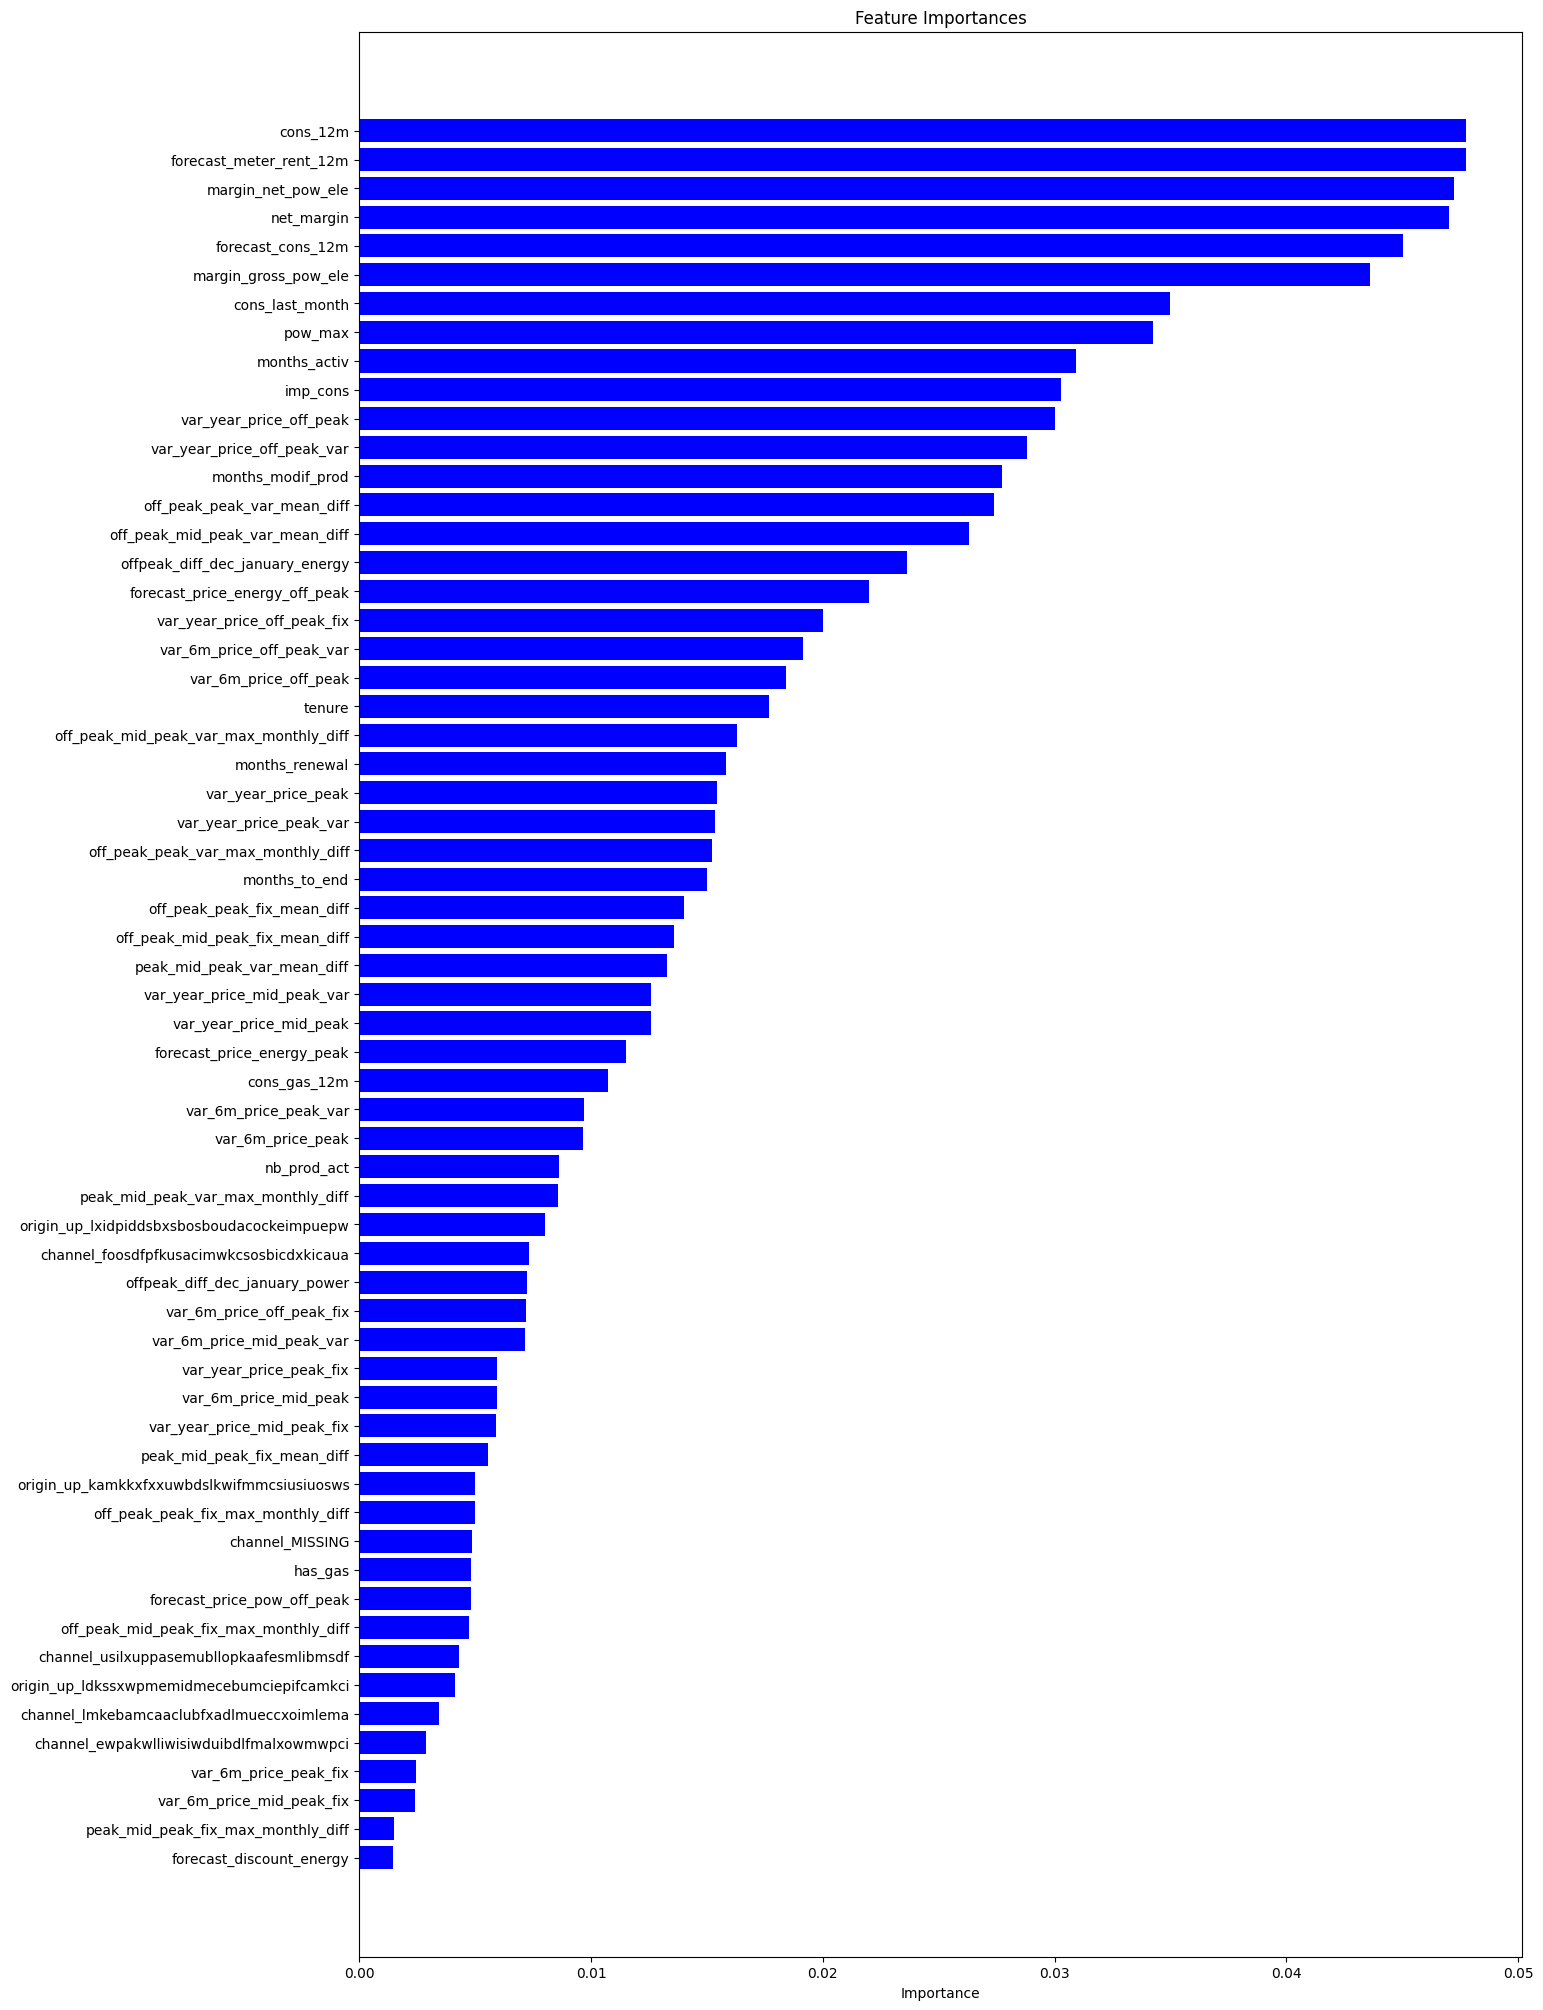

In [ ]:
plt.figure(figsize=(15, 25))
plt.title('Feature Importances')
plt.barh(range(len(feature_importances)), feature_importances['importance'], color='b', align='center')
plt.yticks(range(len(feature_importances)), feature_importances['features'])
plt.xlabel('Importance')
plt.show()

From this chart, we can observe the following points:

- Net margin and consumption over 12 months is a top driver for churn in this model
- Margin on power subscription also is an influential driver
- Time seems to be an influential factor, especially the number of months they have been active, their tenure and the number of months since they updated their contract
- The feature that our colleague recommended is in the top half in terms of how influential it is and some of the features built off the back of this actually outperform it
- Our price sensitivity features are scattered around but are not the main driver for a customer churning

The last observation is important because this relates back to our original hypothesis:

    > Is churn driven by the customers' price sensitivity?

Based on the output of the feature importances, it is not a main driver but it is a weak contributor. However, to arrive at a conclusive result, more experimentation is needed.

In [ ]:
test_predictions = final_model.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, test_predictions).ravel()

In [ ]:
y_test.value_counts()

,count
churn,
0,1304
1,157


In [ ]:
proba_predictions = final_model.predict_proba(X_test)
probabilities = proba_predictions[:, 1]

In [ ]:
X_test = X_test.reset_index()
X_test.drop(columns='index', inplace=True)

In [ ]:
X_test['churn'] = test_predictions.tolist()
X_test['churn_probability'] = probabilities.tolist()
X_test.to_csv('/content/drive/MyDrive/Job Simulations/BCG-X/out_of_sample_data_with_predictions.csv')

###Summarizing Model Evaluation
* We decide how to evaluate the performance of the model. In general, you want to use metrics that reflect honestly how well the model has performed.
* In the example notebook we use 3 metrics, accuracy, precision and recall.
* The reason why we are using these three metrics is because a simple accuracy measure (what percentage was predicted correctly) is not always a good measure to use when there isn't an equal split between categories (e.g., churn is the category we care most about but is only 10% of the data).
* After calculating the 3 metrics, we can see that we’re able to accurately identify clients that do not churn, but not so accurately identify clients that will churn. Our model is predicting a high percentage of clients to not churn, when in fact they did!
* This suggests that more work needs to be done on feature engineering and model tuning to reduce the number of false negatives in our predictions.


Finally, we produce a feature importance chart to visualize which features were indeed useful within the model and which ones weren’t.

* We can see that net margin and consumption over 12 months were important predictors of churn.
* However the price sensitivity features are scattered around and do not shine through as a main driver for churn in their current form.